<a href="https://colab.research.google.com/github/Animeshupgrade/21-Days-21-ML-projects/blob/main/Img_Classification_With_Transfer_Leraning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 9

# Transfer Learning with Pre-trained Models on CIFAR-100

## Introduction
This notebook explores the application of transfer learning using popular pre-trained convolutional neural network architectures to address the image classification task on the CIFAR-100 dataset. Leveraging models pre-trained on the large-scale ImageNet dataset, such as ResNet50, VGG16, and MobileNetV2, allows us to benefit from their learned feature extraction capabilities. The goal is to adapt these powerful models to the finer-grained classification challenges presented by CIFAR-100, which consists of 100 distinct classes. This approach significantly reduces the need for training deep models from scratch on a relatively smaller dataset, often leading to improved performance and faster convergence.

## Project Flow

1.  **Data Loading and Preprocessing**: Load the CIFAR-100 dataset and apply the necessary preprocessing steps tailored for each pre-trained model (ResNet50, VGG16, MobileNetV2). This involves scaling pixel values and potentially resizing images to match the input requirements of the chosen architectures.

2.  **Model Preparation**:
    *   Load pre-trained models (ResNet50, VGG16, MobileNetV2) without their top classification layers.
    *   Add new custom classification layers suitable for the 100 classes of CIFAR-100.
    *   Freeze the layers of the pre-trained base models to retain the learned features during initial training.
    *   Compile the models with an appropriate optimizer, loss function, and metrics.

3.  **Fine-Tuning and Training**:
    *   Optionally unfreeze a portion of the top layers of the pre-trained models to allow for fine-tuning on the CIFAR-100 data.
    *   Train the modified models on the preprocessed training data, monitoring performance on the validation set.

4.  **Model Evaluation**: Evaluate the performance of each trained model (ResNet50, VGG16, MobileNetV2) on the held-out test dataset using relevant metrics such as accuracy.

5. **Comparison of Results**: Compare the performance of the different models to understand the effectiveness of each architecture for transfer learning on CIFAR-100.

# Data Loading and preprocessing

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar100

from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet50
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg16
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenetv2

In [2]:
# splilt the datasets
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

x_train_resnet50 = preprocess_resnet50(x_train)
x_test_resnet50 = preprocess_resnet50(x_test)

x_train_vgg16 = preprocess_vgg16(x_train)
x_test_vgg16 = preprocess_vgg16(x_test)

x_train_mobilenetv2 = preprocess_mobilenetv2(x_train)
x_test_mobilenetv2 = preprocess_mobilenetv2(x_test)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


# Model preparation

Load and modify pretrained model to fit the cifar-100 classification task

In [3]:
#Load pretrained base model
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights = 'imagenet'
    , include_top = False
    , input_shape = (32,32,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# Freeze base model
#pretrained features are not destroyed initially

for layer in base_model.layers:
  layer.trainable = False

In [5]:
# Add custom classification head
# 100 classes-> replaces top layers

from tensorflow.keras import layers,models
x = base_model.output

# Feature Aggregation
x= layers.GlobalAveragePooling2D()(x)

#Regularzation + Learning Capacity

x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

# Final classification layer
outputs = layers.Dense(100, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

In [6]:
# Compile the model
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy', # Changed to sparse_categorical_crossentropy
    metrics=['accuracy']
)

In [7]:
# Model summery
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 24,146,148 (92.11 MB)

 Trainable params: 554,340 (2.11 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

# 2.2 using  VGG16

In [8]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Load pre-trained VGG16 model without the top layer
base_model_vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
# Add new layers
x = GlobalAveragePooling2D()(base_model_vgg16.output)
x = Dense(512, activation='relu')(x)
predictions = Dense(100, activation='softmax')(x)
model_vgg16 = Model(inputs=base_model_vgg16.input, outputs=predictions)

model_vgg16.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Using MobileNetV2

In [9]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Load pre-trained MobileNetV2 model without the top layer
base_model_mobilenetv2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
# Add new layers
x = GlobalAveragePooling2D()(base_model_mobilenetv2.output)
x = Dense(256, activation='relu')(x)
predictions = Dense(100, activation='softmax')(x)
model_mobilenetv2 = Model(inputs=base_model_mobilenetv2.input, outputs=predictions)

model_mobilenetv2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/tmp/ipykernel_2343/3794676327.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model_mobilenetv2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Fine Tuning and Training

In [13]:
epochs = 3

print(len(model.layers)) # Changed model_resnet50 to model
print(len(model_vgg16.layers))
print(len(model_mobilenetv2.layers))


# Fine-tuning ResNet50
for layer in model.layers[:-30]: # Changed model_resnet50 to model
    layer.trainable = False

for layer in model.layers[-30:]: # Changed model_resnet50 to model
    layer.trainable = True

history_resnet50 = model.fit(x_train_resnet50, y_train, epochs=epochs, validation_data=(x_test_resnet50, y_test)) # Changed model_resnet50 to model and X_train/X_test to x_train/x_test



# Fine-tuning VGG16
for layer in model_vgg16.layers[:-5]:
    layer.trainable = False

for layer in model_vgg16.layers[-5:]:
    layer.trainable = True

history_vgg16 = model_vgg16.fit(x_train_vgg16, y_train, epochs=epochs, validation_data=(x_test_vgg16, y_test)) # Changed X_train/X_test to x_train/x_test



# Fine-tuning MobileNetV2
for layer in model_mobilenetv2.layers[:-40]:
    layer.trainable = False

for layer in model_mobilenetv2.layers[-40:]:
    layer.trainable = True

history_mobilenetv2 = model_mobilenetv2.fit(x_train_mobilenetv2, y_train, epochs=epochs, validation_data=(x_test_mobilenetv2, y_test)) # Changed X_train/X_test to x_train/x_test

180
22
157
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1510s 966ms/step - accuracy: 0.3990 - loss: 2.3953 - val_accuracy: 0.4273 - val_loss: 2.3244
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1530s 971ms/step - accuracy: 0.4384 - loss: 2.2004 - val_accuracy: 0.4371 - val_loss: 2.2776
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1474s 943ms/step - accuracy: 0.4737 - loss: 2.0277 - val_accuracy: 0.4435 - val_loss: 2.2866
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 497s 318ms/step - accuracy: 0.1190 - loss: 3.5134 - val_accuracy: 0.1558 - val_loss: 3.3380
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 494s 316ms/step - accuracy: 0.1670 - loss: 3.2280 - val_accuracy: 0.1809 - val_loss: 3.1705
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 503s 317ms/step - accuracy: 0.1918 - loss: 3.1034 - val_accuracy: 0.1826 - val_loss: 3.1513
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 110s 65ms/step - accuracy: 0.1796 - loss: 3.4452 - val_accuracy: 0.1151 - val_loss: 4.5228
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 100s 64ms/step 

# Model Evaluation

In [16]:
acc_resnet50    = model.evaluate(x_test_resnet50, y_test)[1]
acc_vgg16       = model_vgg16.evaluate(x_test_vgg16, y_test)[1]
acc_mobilenetv2 = model_mobilenetv2.evaluate(x_test_mobilenetv2, y_test)[1]

print(f'ResNet50 Accuracy: {acc_resnet50:.2f}')
print(f'VGG16 Accuracy: {acc_vgg16:.2f}')
print(f'MobileNetV2 Accuracy: {acc_mobilenetv2:.2f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 85ms/step - accuracy: 0.4435 - loss: 2.2866
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 240ms/step - accuracy: 0.1826 - loss: 3.1513
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.2734 - loss: 3.2890
ResNet50 Accuracy: 0.44
VGG16 Accuracy: 0.18
MobileNetV2 Accuracy: 0.27


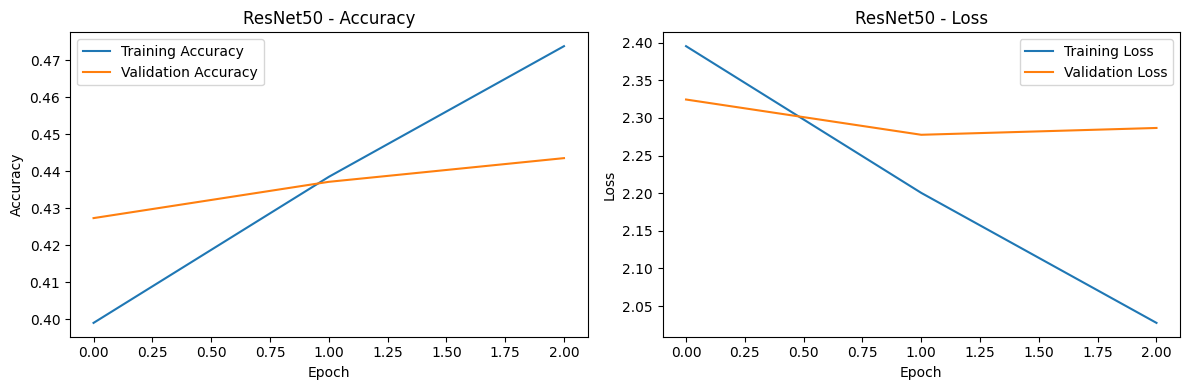

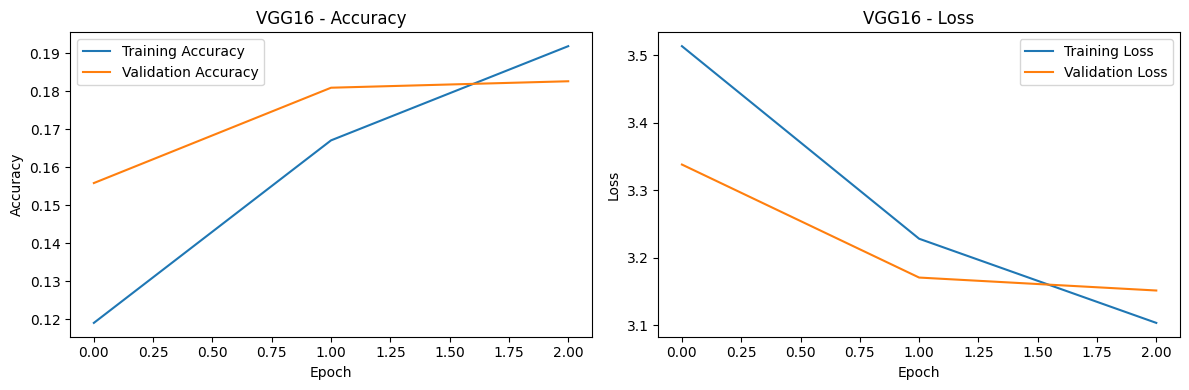

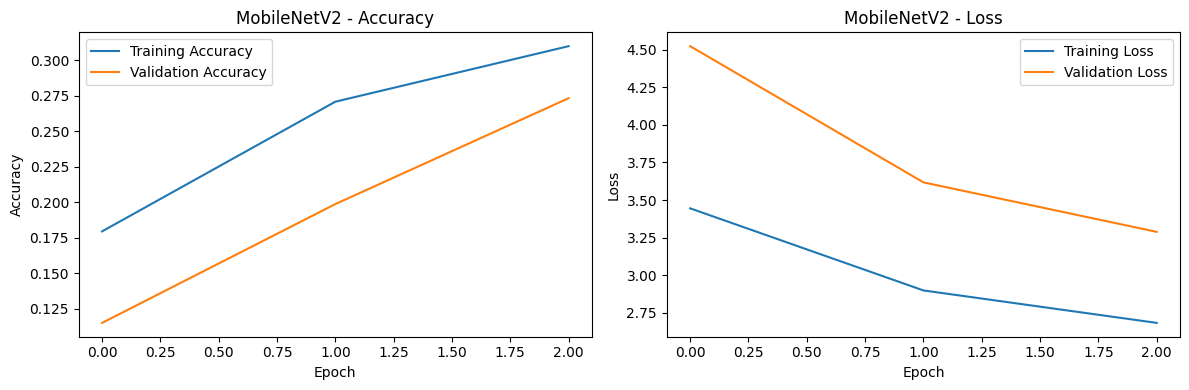

In [17]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    """Plots training and validation accuracy and loss."""
    plt.figure(figsize=(12, 4))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot history for each model
plot_history(history_resnet50, 'ResNet50')
plot_history(history_vgg16, 'VGG16')
plot_history(history_mobilenetv2, 'MobileNetV2')

In [19]:
# Save the models
model.save('resnet50_cifar100.h5')
model_vgg16.save('vgg16_cifar100.h5')
model_mobilenetv2.save('mobilenetv2_cifar100.h5')

# ## Deploying to Streamlit - Step-by-step Guide

This section outlines how to create a basic Streamlit application to load one of the trained models and make predictions on uploaded images.

### Step 1: Install Streamlit

In [21]:
pip install streamlit tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 52.7 MB/s eta 0:00:00


# ### Step 2: Create a Streamlit Application File

You'll need to create a Python file (e.g., `app.py`) for your Streamlit application. Since you're in Colab, you can create and download this file directly. This file will contain all the logic for your Streamlit app.

Below is the content for a sample `app.py` file. This example focuses on the `ResNet50` model. You can replicate this process for VGG16 and MobileNetV2, adjusting the model loading and preprocessing functions accordingly. Copy this code into a file named `app.py` on your local machine.

In [22]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet50
import numpy as np
from PIL import Image
import io

# Load the trained ResNet50 model
@st.cache_resource
def load_model():
    model = tf.keras.models.load_model('resnet50_cifar100.h5')
    return model

model = load_model()

st.title('CIFAR-100 Image Classifier (ResNet50)')
st.write('Upload an image and the model will predict its class.')

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Display the uploaded image
    image_bytes = uploaded_file.read()
    img = Image.open(io.BytesIO(image_bytes))
    st.image(img, caption='Uploaded Image.', use_column_width=True)
    st.write("")
    st.write("Classifying...")

    # Preprocess the image for ResNet50
    # ResNet50 expects 224x224, but our model was trained on 32x32
    # We need to resize and preprocess as per the model's training
    img_resized = img.resize((32, 32))
    img_array = image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
    processed_img = preprocess_resnet50(img_array)

    # Make prediction
    predictions = model.predict(processed_img)
    predicted_class_index = np.argmax(predictions[0])
    confidence = np.max(predictions[0])

    # CIFAR-100 classes are integers, usually mapped to names.
    # For this example, we'll just show the index and confidence.
    # In a real app, you would have a list of 100 class names.
    st.success(f'Prediction: Class {predicted_class_index} (Confidence: {confidence:.2f})')

    # Optional: Display top N predictions
    top_n = 5
    top_indices = np.argsort(predictions[0])[-top_n:][::-1]
    st.write(f"Top {top_n} predictions:")
    for i, idx in enumerate(top_indices):
        st.write(f"- Class {idx}: {predictions[0][idx]:.2f}")

Overwriting app.py


# Running the app on local machine according to instruction

   Drive Link: https://drive.google.com/file/d/1YC5M9i3cnEsFSR-VNb51Bb7teng1C-6g/view?usp=sharing

   Drive Link: https://drive.google.com/file/d/1Kt3TcXBgQVoL8pd_M9akUg0fpXhkQlYZ/view?usp=sharing

## Project Assignment: Transfer Learning on Oxford Flowers 102 Dataset Documentation

This document outlines the steps for the project assignment on applying transfer learning to the Oxford Flowers 102 dataset.

**Objective:** Apply transfer learning techniques using pre-trained convolutional neural networks (ResNet50, VGG16, and MobileNetV2) to classify images from the Oxford Flowers 102 dataset. Compare the performance of the different models on this dataset.

**Dataset:** Oxford Flowers 102 - A dataset of 102 categories of flowers. You will load this dataset using TensorFlow Datasets.

**Assignment Steps:**

1.  **Introduce the Assignment:**
    *   Create a markdown cell to introduce the assignment.
    *   Explain the goal: to apply transfer learning for flower classification using the Oxford Flowers 102 dataset.
    *   Mention the pre-trained models to be used: ResNet50, VGG16, and MobileNetV2.
    *   Briefly describe the Oxford Flowers 102 dataset.

2.  **Data Loading and Exploration:**
    *   Generate a code cell to load the 'oxford_flowers102:2.1.1' dataset using `tfds.load()`. (Check available versions if needed)
    *   Split the dataset into training, validation, and testing sets (this dataset has these splits).
    *   Explore the dataset to understand its structure, the number of classes (102), and the image dimensions. You can display some sample images and their labels.

3.  **Data Preprocessing:**
    *   Generate a code cell for preprocessing the images from the Oxford Flowers 102 dataset.
    *   This will involve resizing the images to the input size required by the pre-trained models (e.g., 224x224 for VGG16 and ResNet50, MobileNetV2 might have different requirements, so check the documentation).
    *   Apply the model-specific preprocessing functions (e.g., `tf.keras.applications.resnet50.preprocess_input`) to normalize the pixel values.
    *   Apply one-hot encoding to the labels.
    *   Batch and prefetch the datasets for efficient training.

4.  **Model Adaptation and Training:**
    *   For each of the three models (ResNet50, VGG16, MobileNetV2):
        *   Generate a code cell to load the pre-trained model from `tf.keras.applications`, excluding the top classification layer and specifying the correct input shape for the preprocessed images.
        *   Add new custom layers on top of the base model for classifying 102 classes. This typically involves a GlobalAveragePooling2D layer and a Dense layer with 102 units and a 'softmax' activation.
        *   Freeze the layers of the pre-trained base model.
        *   Compile the model with an appropriate optimizer (e.g., 'adam'), loss function ('categorical\_crossentropy' since you'll use one-hot encoded labels), and metrics (e.g., 'accuracy').
        *   Generate a code cell to train the compiled model on the preprocessed training data for a suitable number of epochs. Use the validation data to monitor performance during training. Consider using callbacks like ModelCheckpoint and EarlyStopping.
        *   Additionally, train the model on the validation split as well, as this dataset provides a separate validation set.
        *   Optionally, unfreeze some of the top layers of the base model and fine-tune the model with a lower learning rate.

5.  **Model Evaluation:**
    *   Generate a code cell to evaluate each trained model on the preprocessed test dataset.
    *   Print the loss and accuracy for each model.

6.  **Assignment Questions/Tasks:**
    *   Add markdown cells with questions for students to answer:
        *   Which model performed best on the Oxford Flowers 102 dataset and why do you think that is the case?
        *   Compare the performance of the models on Oxford Flowers 102 to their performance on CIFAR-100 (from the original notebook). What differences do you observe and why?
        *   Discuss the effect of transfer learning on this dataset.
        *   Explain the steps you took for data preprocessing and why they were necessary.
        *   Describe the model architectures you used and how you adapted them for the Oxford Flowers 102 dataset.
        *   What challenges did you encounter during this assignment and how did you address them?
    *   Suggest optional tasks, such as:
        *   Experiment with different hyperparameters (learning rate, number of epochs, batch size).
        *   Implement data augmentation techniques.
        *   Try fine-tuning different numbers of layers.
        *   Visualize sample predictions and analyze misclassifications.

7.  **Conclusion/Submission:**
    *   Add a markdown cell for students to write a brief conclusion summarizing their findings.
    *   Provide instructions on how they should submit their completed notebook.

#Step 1

#Introduction

In this assignment, we explore the application of transfer learning to solve a multi-class image classification problem. The primary goal is to classify flower images into their respective categories using the Oxford Flowers 102 dataset.

Transfer learning enables us to leverage powerful deep learning models that have already been trained on large-scale datasets such as ImageNet. Instead of training a model from scratch, we reuse the learned feature representations and adapt them to our specific task, resulting in improved performance and reduced training time.

# Objective

The objective of this assignment is to:

Apply transfer learning techniques for image classification
Utilize pre-trained convolutional neural networks
Compare the performance of different architectures
 Pre-trained Models Used

The following pre-trained models will be used:

ResNet50 – known for its deep residual learning and strong performance
VGG16 – a simple yet powerful architecture with uniform layers
MobileNetV2 – a lightweight and efficient model suitable for fast inference

These models are pre-trained on the ImageNet dataset and will be adapted for flower classification by modifying their final layers.

# About the Dataset

The assignment uses the Oxford Flower 102 dataset, which contains:

102 flower categories
Approximately 8,000+ images
Diverse variations in scale, lighting, and background

This dataset is considered a fine-grained classification task, where different classes may have subtle visual differences, making it ideal for evaluating the effectiveness of transfer learning approaches.

# Approach Overview

The workflow for this assignment includes:

Data preprocessing and augmentation
Model preparation using pre-trained networks
Training and fine-tuning
Model evaluation and comparison

# Step 2

# data loading and preparation

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.MO5GYK_2.1.1/oxford_flowers102-test.tfrecord*…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.MO5GYK_2.1.1/oxford_flowers102-validation.tfr…

Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.
Number of classes: 102

Dataset splits:
Train size: 1020
Validation size: 1020
Test size: 6149

Sample image shape: (500, 667, 3)
Label: 72


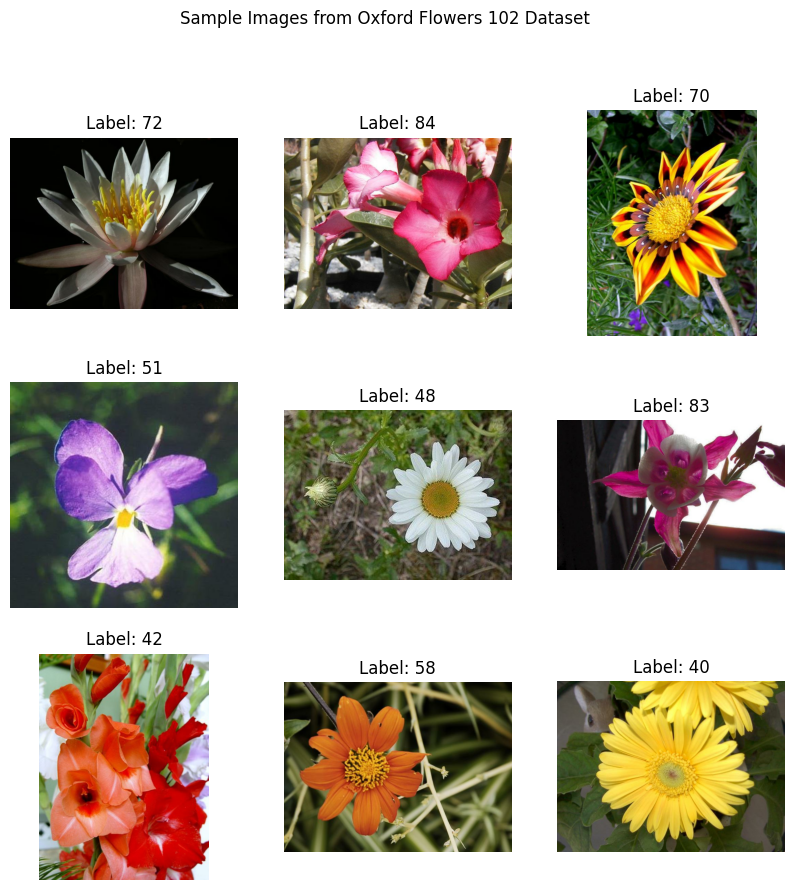

In [23]:
# Step 1: Import Libraries
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

#  Step 2: Load Dataset (specific version if available)
(dataset_train, dataset_val, dataset_test), info = tfds.load(
    'oxford_flowers102:2.1.1',
    split=['train', 'validation', 'test'],
    as_supervised=True,
    with_info=True
)

#  Step 3: Dataset Info
num_classes = info.features['label'].num_classes
print("Number of classes:", num_classes)

print("\nDataset splits:")
print("Train size:", info.splits['train'].num_examples)
print("Validation size:", info.splits['validation'].num_examples)
print("Test size:", info.splits['test'].num_examples)

#  Step 4: Check Image Shape
for image, label in dataset_train.take(1):
    print("\nSample image shape:", image.shape)
    print("Label:", label.numpy())

#  Step 5: Display Sample Images
plt.figure(figsize=(10, 10))

for i, (image, label) in enumerate(dataset_train.take(9)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(f"Label: {label.numpy()}")
    plt.axis("off")

plt.suptitle("Sample Images from Oxford Flowers 102 Dataset")
plt.show()

# Step 3

# Data preprocessing

In [24]:
#  Step: Data Preprocessing Pipeline

import tensorflow as tf

#  Constants
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

NUM_CLASSES = 102  # Oxford Flowers 102

#  Import model-specific preprocessing functions
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess


#  Generic preprocessing function
def preprocess(image, label, preprocess_fn):
    # Resize image
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    # Convert to float32 (important before preprocessing)
    image = tf.cast(image, tf.float32)

    # Apply model-specific preprocessing
    image = preprocess_fn(image)

    # One-hot encode labels
    label = tf.one_hot(label, NUM_CLASSES)

    return image, label


#  Create pipelines for each model

#  ResNet50
train_resnet = dataset_train.map(lambda x, y: preprocess(x, y, resnet_preprocess)) \
                           .shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_resnet = dataset_val.map(lambda x, y: preprocess(x, y, resnet_preprocess)) \
                       .batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_resnet = dataset_test.map(lambda x, y: preprocess(x, y, resnet_preprocess)) \
                        .batch(BATCH_SIZE).prefetch(AUTOTUNE)


#  VGG16
train_vgg = dataset_train.map(lambda x, y: preprocess(x, y, vgg_preprocess)) \
                         .shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_vgg = dataset_val.map(lambda x, y: preprocess(x, y, vgg_preprocess)) \
                     .batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_vgg = dataset_test.map(lambda x, y: preprocess(x, y, vgg_preprocess)) \
                      .batch(BATCH_SIZE).prefetch(AUTOTUNE)


#  MobileNetV2
train_mobilenet = dataset_train.map(lambda x, y: preprocess(x, y, mobilenet_preprocess)) \
                               .shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_mobilenet = dataset_val.map(lambda x, y: preprocess(x, y, mobilenet_preprocess)) \
                           .batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_mobilenet = dataset_test.map(lambda x, y: preprocess(x, y, mobilenet_preprocess)) \
                            .batch(BATCH_SIZE).prefetch(AUTOTUNE)


print("Preprocessing complete for all models!")

Preprocessing complete for all models!


# Step 4

# Model adaptation and training

In [25]:
# Build and compile model
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, VGG16, MobileNetV2

IMG_SIZE = 224
NUM_CLASSES = 102

def build_transfer_model(base_model_fn, input_shape=(IMG_SIZE, IMG_SIZE, 3), dense_units=256, dropout=0.5):
    # Load base (no top)
    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze base
    base_model.trainable = False

    # Custom head
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)

    # Compile
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base_model

# Build models
resnet_model, resnet_base = build_transfer_model(ResNet50, dense_units=256, dropout=0.5)
vgg_model, vgg_base       = build_transfer_model(VGG16,    dense_units=512, dropout=0.5)
mobilenet_model, mobilenet_base = build_transfer_model(MobileNetV2, dense_units=128, dropout=0.4)

# (Optional) Summaries
# resnet_model.summary()
# vgg_model.summary()
# mobilenet_model.summary()

In [26]:
# Train the Frozen base

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

EPOCHS = 15

callbacks_common = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
]

# Separate checkpoints for each model
ckpt_resnet = ModelCheckpoint("resnet50_best.h5", monitor='val_accuracy', save_best_only=True)
ckpt_vgg    = ModelCheckpoint("vgg16_best.h5",    monitor='val_accuracy', save_best_only=True)
ckpt_mob    = ModelCheckpoint("mobilenetv2_best.h5", monitor='val_accuracy', save_best_only=True)

# --- ResNet50 ---
history_resnet = resnet_model.fit(
    train_resnet,
    validation_data=val_resnet,
    epochs=EPOCHS,
    callbacks=callbacks_common + [ckpt_resnet]
)

# --- VGG16 ---
history_vgg = vgg_model.fit(
    train_vgg,
    validation_data=val_vgg,
    epochs=EPOCHS,
    callbacks=callbacks_common + [ckpt_vgg]
)

# --- MobileNetV2 ---
history_mobilenet = mobilenet_model.fit(
    train_mobilenet,
    validation_data=val_mobilenet,
    epochs=EPOCHS,
    callbacks=callbacks_common + [ckpt_mob]
)

Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0214 - loss: 5.6215

32/32 ━━━━━━━━━━━━━━━━━━━━ 266s 8s/step - accuracy: 0.0225 - loss: 5.5556 - val_accuracy: 0.0333 - val_loss: 4.6165
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0500 - loss: 4.8123

32/32 ━━━━━━━━━━━━━━━━━━━━ 224s 7s/step - accuracy: 0.0520 - loss: 4.7341 - val_accuracy: 0.0804 - val_loss: 4.3039
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1027 - loss: 4.2881

32/32 ━━━━━━━━━━━━━━━━━━━━ 253s 8s/step - accuracy: 0.1098 - loss: 4.1926 - val_accuracy: 0.1657 - val_loss: 4.0087
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1701 - loss: 3.6777

32/32 ━━━━━━━━━━━━━━━━━━━━ 223s 7s/step - accuracy: 0.1745 - loss: 3.6078 - val_accuracy: 0.2402 - val_loss: 3.7219
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2665 - loss: 3.1822

...

32/32 ━━━━━━━━━━━━━━━━━━━━ 764s 24s/step - accuracy: 0.0255 - loss: 5.0289 - val_accuracy: 0.0402 - val_loss: 4.6718
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.0333 - loss: 4.7337 

32/32 ━━━━━━━━━━━━━━━━━━━━ 793s 24s/step - accuracy: 0.0353 - loss: 4.6807 - val_accuracy: 0.0706 - val_loss: 4.3656
Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - accuracy: 0.0090 - loss: 5.3391

32/32 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.0118 - loss: 5.3041 - val_accuracy: 0.0196 - val_loss: 4.6753
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.0191 - loss: 5.0175

32/32 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.0275 - loss: 4.9307 - val_accuracy: 0.0343 - val_loss: 4.5113
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.0511 - loss: 4.6025

32/32 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.0500 - loss: 4.5836 - val_accuracy: 0.0657 - val_loss: 4.3535


# Step 5

# Model Evaluation

In [28]:
#  Model Evaluation on Test Dataset

# --- ResNet50 ---
resnet_loss, resnet_acc = resnet_model.evaluate(test_resnet)
print("\n ResNet50 Performance:")
print(f"Test Loss: {resnet_loss:.4f}")
print(f"Test Accuracy: {resnet_acc:.4f}")

# VGG16
vgg_loss, vgg_acc = vgg_model.evaluate(test_vgg)
print("\n VGG16 Performance:")
print(f"Test Loss: {vgg_loss:.4f}")
print(f"Test Accuracy: {vgg_acc:.4f}")

#MobileNetV2
mobilenet_loss, mobilenet_acc = mobilenet_model.evaluate(test_mobilenet)
print("\n MobileNetV2 Performance:")
print(f"Test Loss: {mobilenet_loss:.4f}")
print(f"Test Accuracy: {mobilenet_acc:.4f}")

193/193 ━━━━━━━━━━━━━━━━━━━━ 669s 3s/step - accuracy: 0.7167 - loss: 1.4792

 ResNet50 Performance:
Test Loss: 1.4792
Test Accuracy: 0.7167
193/193 ━━━━━━━━━━━━━━━━━━━━ 2293s 12s/step - accuracy: 0.0585 - loss: 4.6302

 VGG16 Performance:
Test Loss: 4.6302
Test Accuracy: 0.0585
193/193 ━━━━━━━━━━━━━━━━━━━━ 137s 709ms/step - accuracy: 0.0241 - loss: 4.6590

 MobileNetV2 Performance:
Test Loss: 4.6590
Test Accuracy: 0.0241
